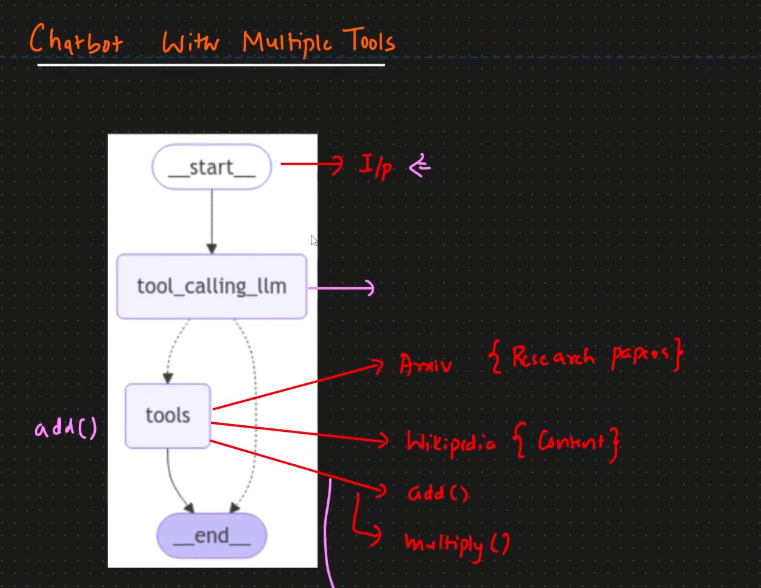

Create a chatbot with tool capabilities from arxiv, wikipedia search, tavily and more functions

In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [8]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=5, doc_content_chars_max=5000)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)



arxiv


In [9]:
from pprint import pprint
pprint(arxiv.invoke("Attention is all you need"))

('Published: 2021-05-06\n'
 'Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does '
 'Surprisingly Well on ImageNet\n'
 'Authors: Luke Melas-Kyriazi\n'
 'Summary: The strong performance of vision transformers on image '
 'classification and other vision tasks is often attributed to the design of '
 'their multi-head attention layers. However, the extent to which attention is '
 'responsible for this strong performance remains unclear. In this short '
 'report, we ask: is the attention layer even necessary? Specifically, we '
 'replace the attention layer in a vision transformer with a feed-forward '
 'layer applied over the patch dimension. The resulting architecture is simply '
 'a series of feed-forward layers applied over the patch and feature '
 'dimensions in an alternating fashion. In experiments on ImageNet, this '
 'architecture performs surprisingly well: a ViT/DeiT-base-sized model obtains '
 '74.9\\% top-1 accuracy, compared to 77.9\\% and 79.9\\% for ViT a

Wikipedia

In [10]:
api_wikipedia_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wikipedia_wrapper)
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\n\nStat'

In [12]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [15]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=5, topic="general")
tavily_tool.invoke("What's happening with LPG crisis in India? Explain the reason")


{'query': "What's happening with LPG crisis in India? Explain the reason",
 'response_time': 0.84,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.outlookbusiness.com/economy-and-policy/indias-lpg-crisis-explained-whats-fuelling-it-and-what-its-costing-you',
   'title': "India's LPG Crisis Explained: What's Fuelling It and What It's Costing You",
   'content': '# India’s LPG Crisis Explained: What’s Fuelling It and What It’s Costing You. The near-closure of the Strait of Hormuz has disrupted LPG and LNG supplies to India, exposing the country’s limited gas reserves and pushing up costs for households, restaurants, and the government. Escalating tensions in West Asia and the near-closure of the Strait of Hormuz have disrupted LPG and LNG shipments to India. Unlike crude oil, India has minimal strategic reserves for LPG and LNG, leaving the country vulnerable to supply shocks. Beyond the volatility in crude oil prices, India’s supply of liq

Combine all the tools in a list

In [32]:
tools = [arxiv, wiki, tavily_tool]

In [26]:
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage

chat = ChatGroq(model="qwen/qwen3-32b")
chat_using_tools = chat.bind_tools(tools)
messages = [HumanMessage(content=("What is a world war"), name="Kishore")]
res = chat_using_tools.invoke(messages)
pprint(res)

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is a world war." I need to provide a clear and concise definition. First, I should check if there\'s a general definition available through Wikipedia since that\'s a good source for foundational information. The user isn\'t specifying a particular instance like World War I or II, so a general explanation would be best. I\'ll use the wikipedia function to look up "world war" to get an overview. That should cover the historical context, scale, and impact of world wars. I don\'t think I need to use arxiv or tavily_search here because it\'s a general question, not requiring current events or academic papers. Let me call the Wikipedia function with the query "world war".\n', 'tool_calls': [{'id': 'nag7b6mv0', 'function': {'arguments': '{"query":"world war"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 171, 'prompt_tokens': 1915, 'total_token

In [19]:
res.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search (pf076jc2k)
 Call ID: pf076jc2k
  Args:
    query: AI
    search_depth: advanced
    time_range: day


### Let's build a chatbot with these tools in langgraph

In [25]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

# Define state class with variables
class State(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]

In [27]:
# Node 

def tool_calling_llm(state:State):
    res_msg_list = [chat_using_tools.invoke(state["messages"])]
    return res_msg_list


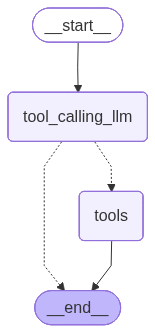

In [34]:
# Build graph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              # tools_condition decides whether the any tool should be invoked or go directly to end
                              tools_condition,
                              )
builder.add_edge("tools", END)

graph = builder.compile()

#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))


In [37]:
graph.invoke({"messages":HumanMessage(content="What is machine learning")})

InvalidUpdateError: Expected dict, got [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is machine learning?" I need to provide a clear and concise explanation. Let me start by recalling the basics of machine learning. It\'s a subset of artificial intelligence that involves algorithms learning patterns from data. I should mention supervised, unsupervised, and reinforcement learning as the main types. Maybe include examples like classification, regression, clustering. Also, it\'s important to note applications in various fields such as image recognition, natural language processing, etc. Wait, do I need to use any of the provided tools here? The user\'s question is pretty general, so perhaps Wikipedia would be a good source for a foundational definition. Let me check the available functions. The \'wikipedia\' function is there for general questions. I should call that with the query "machine learning" to get an accurate summary. That way, th

In [38]:
graph.invoke({"messages":HumanMessage(content="Research paper - Attention is all you need")})

InvalidUpdateError: Expected dict, got [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the research paper "Attention is All You Need." I need to figure out which tool to use here. Let me check the available functions.\n\nFirst, the Arxiv function is for physics, math, computer science, and other quantitative fields. Since this paper is about transformer models and attention mechanisms, which are in computer science and machine learning, Arxiv is a good bet. The paper was published there.\n\nWikipedia might have a summary, but the user probably wants the original paper. Tavily search could find it too, but Arxiv is more direct for academic papers. Let me confirm: "Attention is All You Need" by Vaswani et al. is indeed on Arxiv. So using the arxiv function with the query "Attention is All You Need" should retrieve it. No need for other parameters since the user didn\'t specify a date or domain. I\'ll go with the arxiv function.\n', 'tool_cal